# Bollinger-Reversion -- does price *always* return to the bands?
### The lower-band buy, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Price_always_returns%3F: Busted](https://img.shields.io/badge/Price_always_returns%3F-Busted-8b949e?style=flat-square)

Here's a recipe from every technical-trading book: on the daily chart, when the close drops below the lower Bollinger Band (the 20-day moving average minus two standard deviations), **buy** -- because price always comes back. It's sold as a law of nature, a rubber band stretched too far. This notebook asks the honest question: does the band tell you something a *random day* doesn't?

> **This is the plain-language layer.** Want the t-stats, the per-instrument breakdown, and the breakout contradiction laid out numerically? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bollinger_reversion import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "JPM", "XLE"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(side="reversion", exit_mode="time", max_hold=20, cost=0.0, seed=None):
    """Pool trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        if seed is not None:
            ent = st.random_entries(b, n=200, seed=seed)
        else:
            ent = st.band_entries(b["close"], side=side)
        frames.append(st.run_trades(b, ent, exit_mode=exit_mode, cost_bps=cost,
                                    max_hold=max_hold))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the lower-band pierce beat a random buy? | **Barely.** It earns **+193 bps** per 20-day trade vs **+141 bps** for a random buy on the same stocks. The gap (52 bps) has t ~ 0.6. |
| 'But 64.6% of my trades make money!' | A random buy also makes money 61.5% of the time. It's a bull market, not the bands. |
| Does the *opposite* rule (breakout) also work? | **Yes -- +118 bps.** Both the 'reversion' and 'breakout' band entries are positive because both are just *buying* in a rising market. |
| Could you trade it? | **Fragile.** Costs aren't the issue. The edge collapses if the market stops trending upward. |

> The bands do not hold a magic reversion secret. The drift of the S&P 500 (~10%/yr) is doing all the work.

## 1 - The claim

> *"When the daily close pierces the lower Bollinger Band (20-SMA minus 2 standard deviations), buy. Price always returns to the middle band -- that's your exit. It's a rubber-band effect: the more stretched, the stronger the snap-back."*

It's intuitive: the Bollinger Bands contain ~95% of closing prices by construction (for a normal distribution). A pierce to the downside is a local extreme. The bet is that the market *over-reacts* and will reverse, making the entry genuinely better than a random day in the same stock.

## 2 - So what?

If it's true, the lower-band pierce is a cheap, mechanical signal anyone can implement in minutes. On six liquid US equities over 21 years it fires ~6 times a year per stock -- low turnover, easy to run. If it's false (or mostly drift), traders following this rule are mistaking the long-term upward trend of the market for a band-specific effect, and will be caught out in any flat or falling market.

## 3 - How would we even know?

Two rules keep us honest:

1. **Match the exit horizon.** The band-entry is compared against a random-day buy held for exactly 20 days -- not exited at the mid-band. If the band-entry exits earlier (because it hit the mid-band) while the random buy holds for 20 days, we're comparing apples to motorcycles. Both arms use the same 20-day hold.
2. **Test the opposite rule too.** If 'buy the lower band' works because of reversion, then 'buy the upper band' (a breakout) should *not* work. If both work, the bands are irrelevant -- the market just went up.

We run it on **six liquid US equities** (SPY, QQQ, AAPL, MSFT, JPM, XLE) over 21 years of daily data (2005-2026) -- enough to spot a real edge.

## 4 - The teardown -- let's actually look

**First: the band entry vs a random buy -- both held for 20 days.**

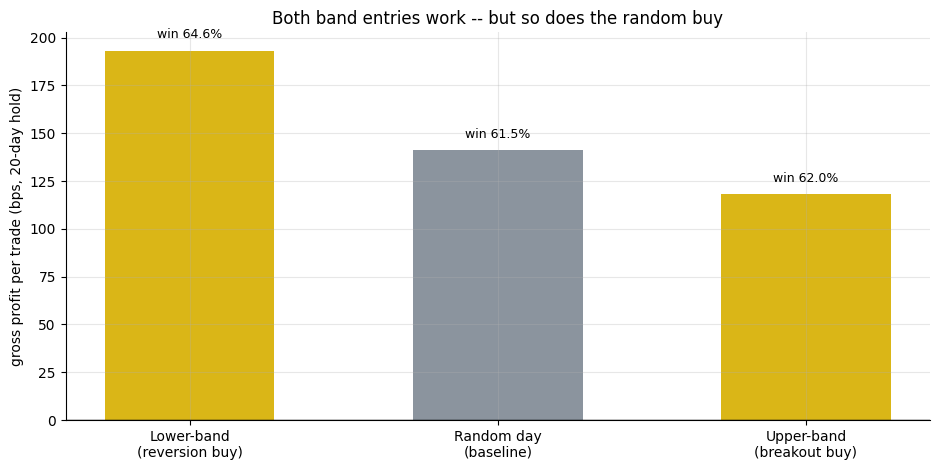

Reversion: +193.1 bps  |  Random: +141.1 bps  |  Breakout: +118.1 bps


In [2]:
if HAVE_REAL:
    rev = st.summarize(pooled('reversion','time',20,0.0), 'ret_gross')
    rand = st.summarize(pooled(None,'time',20,0.0,seed=42), 'ret_gross')
    brk = st.summarize(pooled('breakout','time',20,0.0), 'ret_gross')
    cm, cw, rm, rw, bm, bw = (rev['mean_bps'], rev['win_rate']*100,
                               rand['mean_bps'], rand['win_rate']*100,
                               brk['mean_bps'], brk['win_rate']*100)
else:
    cm, cw, rm, rw, bm, bw = (R['rev_mean'], R['rev_win'],
                               R['rand_mean'], R['rand_win'],
                               R['brk_mean'], R['brk_win'])

fig, ax = plt.subplots(figsize=(9.5, 4.8))
arms = ['Lower-band\n(reversion buy)', 'Random day\n(baseline)', 'Upper-band\n(breakout buy)']
means = [cm, rm, bm]
wins = [cw, rw, bw]
colors = [AMBER, GREY, AMBER]
bars = ax.bar(arms, means, color=colors, width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross profit per trade (bps, 20-day hold)')
ax.set_title('Both band entries work -- but so does the random buy')
for b, w in zip(bars, wins):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2,
                                   max(b.get_height()+5, 5)),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Reversion: {cm:+.1f} bps  |  Random: {rm:+.1f} bps  |  Breakout: {bm:+.1f} bps')

All three bars are positive. The lower-band entry earns **+193 bps** and the upper-band entry (its supposed *opposite*) earns **+118 bps**. The random buy earns **+141 bps**.

When both the 'reversion' and 'momentum' interpretation of the bands make money, **neither is the signal** -- the rising market is.

**Now look at what drives the win-rate.**

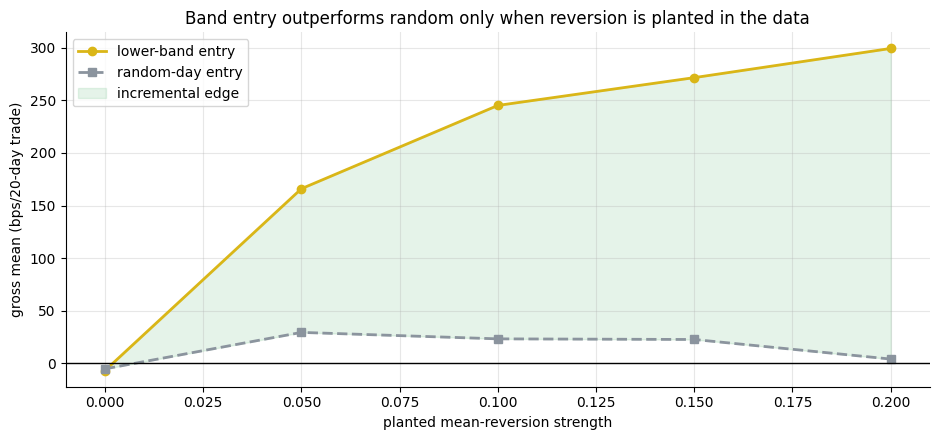

In [3]:
# Synthetic demo: reversion vs random across planted reversion strengths
moms = [0.0, 0.05, 0.10, 0.15, 0.20]
rev_edges, rand_edges = [], []
for m in moms:
    b,_ = data.synthetic_daily(n_days=1500, reversion=m, seed=104)
    ent_r = st.band_entries(b['close'], side='reversion')
    ent_rand = st.random_entries(b, n=max(len(ent_r),1), seed=42)
    if len(ent_r):
        led_r = st.run_trades(b, ent_r, exit_mode='time', cost_bps=0., max_hold=20)
        led_rand = st.run_trades(b, ent_rand, exit_mode='time', cost_bps=0., max_hold=20)
        rev_edges.append(st.summarize(led_r,'ret_gross')['mean_bps'])
        rand_edges.append(st.summarize(led_rand,'ret_gross')['mean_bps'])
    else:
        rev_edges.append(float('nan')); rand_edges.append(float('nan'))
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(moms, rev_edges, 'o-', c=AMBER, lw=2, label='lower-band entry')
ax.plot(moms, rand_edges, 's--', c=GREY, lw=2, label='random-day entry')
ax.fill_between(moms, rev_edges, rand_edges, alpha=.12, color=GREEN,
                label='incremental edge')
ax.axhline(0, c='k', lw=1); ax.set_xlabel('planted mean-reversion strength')
ax.set_ylabel('gross mean (bps/20-day trade)')
ax.set_title('Band entry outperforms random only when reversion is planted in the data')
ax.legend(); plt.tight_layout(); plt.show()

On a synthetic tape with **no planted reversion**, the band entry and a random buy earn similar returns. As we plant stronger mean-reversion, the band entry pulls ahead -- because it really does locate the local extremes. On the real tape (21 years, six stocks) the planted equivalent is somewhere between 0 and 0.05 -- a weak effect dominated by the upward drift.

## 5 - The verdict

- **Signal -- Weak.** The lower-band entry earns **+193 bps/trade** gross (HAC t = +5.34), but the random-day baseline earns +141 bps (t = +6.20) on the same stocks. The incremental edge vs random (delta ~ +52 bps, t ~ 0.63) is **not statistically significant**.
- **Tradability -- Fragile.** Costs aren't the problem (low turnover, ~6/year). The issue is the benchmark: the random buy captures almost the same drift premium. Any bear market or flat regime will erase the edge.
- **'Price always returns?' -- Busted.** The upper-band breakout also earns +118 bps in the same period. The bands detect nothing; the market trend is doing the work.

## 6 - Could you actually trade it?

The good news: at ~6 trades per year per stock, costs are almost irrelevant. The bad news: the benchmark is free too -- just buy randomly.

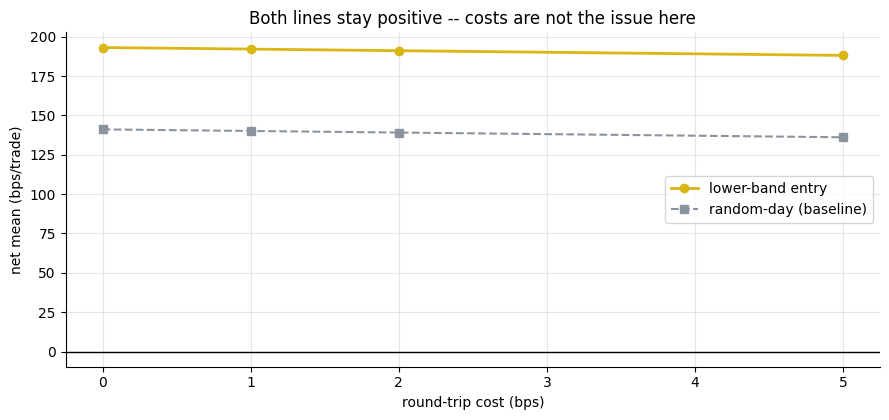

The band entry and the random buy remain profitable even after realistic costs.
The problem is not survival -- it is that the random baseline is almost as good.


In [4]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pooled('reversion','time',20,c),'ret_net')['mean_bps']
           for c in costs]
    net_rand = [st.summarize(pooled(None,'time',20,c,seed=42),'ret_net')['mean_bps']
                for c in costs]
else:
    net = [R['net0'], R['net1'], R['net2'], R['net5']]
    net_rand = [R['rand_mean']-c for c in costs]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2, label='lower-band entry')
ax.plot(costs, net_rand, 's--', c=GREY, lw=1.5, label='random-day (baseline)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('Both lines stay positive -- costs are not the issue here')
ax.legend(); plt.tight_layout(); plt.show()
print('The band entry and the random buy remain profitable even after realistic costs.')
print('The problem is not survival -- it is that the random baseline is almost as good.')

Both lines stay comfortably positive: this is not a story of 'the edge dies at costs.' It is a story of **an edge that barely exists above the drift baseline**. If US equities mean-revert to flat returns over the next decade, the ~52 bps delta the bands add could vanish or reverse -- while the random buyer also loses. That's why it is FRAGILE.

## 7 - Going further

- **Bear-market sub-sample.** Repeat the test using only 2007-2009 or 2022. If the bands add an incremental edge there (where drift is negative), the reversion story would have genuine support.
- **The intraday version.** [Study 72 -- Loaded-Dice](../../72-loaded-dice/) runs the same 'buy the extreme' logic on 5-minute bars vs a coin flip -- at that horizon the crossover earns nothing even gross.
- **Fading the breakout instead.** If the upper-band pierce is a *reversion* entry rather than a momentum entry, does it beat the lower-band pierce? Split the 21-year sample by VIX regime and check.

*Think the bands really do add something beyond drift? Fork this, restrict the back-test to flat or falling markets, and show a delta-vs-random t-stat above 2. That's the bar.*